In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
import re

import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [2]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [18]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [21]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [4]:
## Configs
base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
out = f'{base}/Clustering/M06-4_K-Means'
ipt = f'{base}/Dataset'
SEED = 64

In [8]:
# CLUSTERING :: DATA IMPORT

# Data import
df = pd.read_csv(f"{ipt}/knn_prep-fin_M02-1.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
df

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (30,31,55,61,62,63,87,90,91,92) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,promn,promd,prho,promh,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
1,1,2013-11-15,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
2,1,2013-11-15,1.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,0.0,1.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,0,2022-08-16,0.0,0.0,0.0,0.0,1.0,2022-08-08,11:00,0.0,...,1,0,1,0,0,0,1,0,0,0
17825,1,2022-04-07,1.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,1,0,1,0,0,0,1,0,0,0
17826,0,2022-04-17,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0,0,0,1,0,0,0,1,0,0


In [9]:
drop_cols = ['apguk1', 'apguk5', 'fetc2', 'fetc', 'strduot', 'metc', 'ibifcmt', 'lbpdot'
             , 'bhdcut', 'bhtcut', 'iperrdt', 'phudot', 'phudstdt', 'sftum', 'sftuh', 'sftfudt'
             , 'sftthdt', 'birdm', 'birdh', 'sign'
             , 'promn'    # 01-24 추가됨
            ]

## 접두사로 시작하는 제거칼럼
# prefixes_to_drop = ['mcou_', 'fcou_', 'bsffs1_', 'bsffs2_', 'bsffs3_', 'menifs_']
# drop_cols += [col for col in df.columns if any(col.startswith(prefix) for prefix in prefixes_to_drop)]
datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'acldt', 'birthdt', 'bsfdt1', 'bsfdt3', 'admd'
                 , 'prho', 'promd', 'promh', 'prdh', 'dth36dt'    # 01-24 추가됨 ('promh', 'prdh', 'dth36dt')
                 , 'fsfdt1', 'fsfdt2', 'birtm', 'bird']
drop_cols += datetime_cols
df = df.drop(columns=list(drop_cols))

tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
                                                 , 'invfpod'
                                                 , 'iperr', 'iperroy']
            or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
                                                         , 'invfpod'
                                                         , 'iperr', 'iperroy'])
           ]
data = df.drop(columns=['death36'] + list(tgt_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

df_scd['death36'] = df['death36']

df_scd

,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,menifs_12,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
1,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
2,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.029210,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
3,1.00028,-0.441286,2.037134,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.526262,-0.072549,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
4,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17825,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-1.959000,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17826,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.964895,0.515043,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0


In [10]:
print(len(drop_cols))
print(len(datetime_cols))
print(len(tgt_cols))

42
21
18


In [11]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: sterd1
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: sterd2
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: sterd4
데이터 타입: float64
유니크한 값:
[0. 1.]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.     

In [9]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
bir4,0,0.0,2
...,...,...,...
iperr_4,0,0.0,2
iperroy_1,0,0.0,2
iperroy_4,0,0.0,2
iperroy_3,0,0.0,2


In [10]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
bir4,0,0.0,2
...,...,...,...
menifs_6,0,0.0,2
menifs_33,0,0.0,2
menifs_18,0,0.0,2
menifs_34,0,0.0,2


In [11]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: float64
유니크한 값:
[ 0.99314457 -1.00690275]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[-0.44293495  2.25766785]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[-0.49328065  2.02724352]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[-0.12518078  7.98844707]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[-2.42893084e-02  4.11703777e+01]
----------------------------------------
칼럼 이름: promh
데이터 타입: float64
유니크한 값:
[-0.10733735  3.50644212  0.92517107  1.69955239  1.18329818  7.63647581
  0.15078976  1.44142528  0.66704397  1.95767949  8.66898423  0.40891686
 21.83346659  3.76456923  7.1202216  27.5122629   5.05520476  3.24831502
  6.86209449  5.57145897 13.83152633  6.08771318  2.99018791  4.02269633
  2.4739337   2.2158066   5.31333186 10.47587396 25.18911895 17.1871787
  6.60396739 20.54283106 10.73400107  2.73206081 26.47975448  8.41085

In [12]:
# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100

# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율

# 출력
print("[df_scd (Processed df)]")
print("[1] IPERR")
# print(f"Negatives (0): {survived_ratio:.2f}%")
# print(f"Neg / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
# print()
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Pos / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print("--------------------------------------------------")



# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100

# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율

# 출력
print("[2] NTET")
# print(f"Negatives (0): {survived_ratio:.2f}%")
# print(f"Neg / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
# print()
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Pos / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print("--------------------------------------------------")

[df_scd (Processed df)]
[1] IPERR
Positives (1): 2.38%
Pos / Total : 425 / 17829
--------------------------------------------------
[2] NTET
Positives (1): 6.59%
Pos / Total : 1175 / 17829
--------------------------------------------------


In [13]:
df_scd

,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,menifs_12,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
1,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
2,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.029210,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
3,1.00028,-0.441286,2.037134,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.526262,-0.072549,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
4,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.467843,-1.247733,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17825,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-1.959000,-0.660141,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0
17826,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.964895,0.515043,...,-0.016749,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0


In [153]:
## 각 클러스터에 헤딩하는 인원들만 선별해 클러스터링

re = f'{out}/C4'
df = pd.read_csv((f"{re}/df_scd_clustered.csv"))
df.set_index('idx_code', inplace=True)

# 특정 클러스터 라벨만 사용
selected_clusters = [1, 2]

df = df[df['Cluster_Labels'].isin(selected_clusters)]
df = df.drop(columns=['Cluster_Labels'])

df_scd = df.copy()
df_scd

,sex_sys_val,bir1,bir2,bir3,bir4,promh,prdh,sterd1,sterd2,sterd4,...,menifs_12,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36
idx_code,,,,,,,,,,,,,,,,,,,,,
1,0.993145,-0.442935,-0.493281,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,0.0
3,0.993145,-0.442935,2.027244,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,0.0
7,0.993145,-0.442935,-0.493281,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,0.0
8,-1.006903,-0.442935,2.027244,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,0.0
10,-1.006903,-0.442935,-0.493281,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20401,-1.006903,-0.442935,-0.493281,-0.125181,-0.024289,-0.107337,-0.150809,3.256254,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,1.0
20406,0.993145,-0.442935,-0.493281,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,1.0
20407,0.993145,-0.442935,-0.493281,-0.125181,-0.024289,-0.107337,-0.150809,-0.307101,-0.727613,-0.039058,...,-0.017173,-0.030569,-0.015676,-0.009914,-0.01983,-0.00701,-0.012142,-0.00701,-0.00701,0.0


In [155]:
##### ### # 클러스터링 이후 기존 df를 새로 인가해줘야 함 ! !!! !!!!!

# Data import
df = pd.read_csv(f"{re}/KNN_df_combined.csv")
df.set_index('idx_code', inplace=True)

df = df[df['Cluster_Labels'].isin(selected_clusters)]
original_cluster_labels = df['Cluster_Labels']
df = df.drop(columns=['Cluster_Labels'])
df

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (46,69,72,73) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,promd,prho,promh,prdh,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
7,1,2013-10-08,0.0,0.0,0.0,0.0,2013-10-07,18:00,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
8,0,2013-09-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
10,0,2013-09-25,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20401,0,2022-08-29,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20406,1,2022-11-10,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20407,1,2022-11-06,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0


In [146]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: idx_code
데이터 타입: int64
유니크한 값:
[    1     3     7 ... 20407 20408 20409]
----------------------------------------
칼럼 이름: sex_sys_val
데이터 타입: float64
유니크한 값:
[ 0.99314457 -1.00690275]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[-0.44293495  2.25766785]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[-0.49328065  2.02724352]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[-0.12518078  7.98844707]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[-0.02428931]
----------------------------------------
칼럼 이름: promh
데이터 타입: float64
유니크한 값:
[-0.10733735  3.50644212  0.92517107  1.69955239  1.95767949  8.66898423
  0.40891686  0.15078976  3.24831502 13.83152633  6.08771318  4.02269633
  0.66704397  2.2158066   1.18329818  3.76456923 10.47587396  5.57145897
  6.60396739  1.44142528  2.99018791  2.73206081 26.47975448  8.92711133
  5.05520476  5.82958607 18.47781422 11.

In [14]:
save_dir = out

In [30]:
## WCSS_scores (MiniBatch K-means)

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e47739d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e4773ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e4773ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e47739d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e47739d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e47739d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e4773ee0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

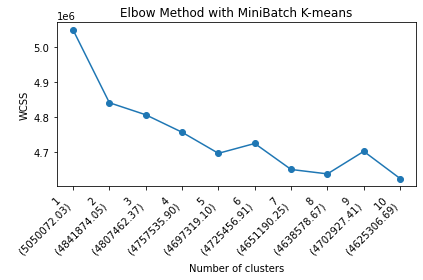

In [15]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])

data_for_clustering = df_scd.drop(columns=['death36'])
data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 11):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=42)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

# 그래프 생성
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i} \n ({w:.2f})' for i, w in enumerate(wcss, 1)]
plt.xticks(range(1, 11), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

In [16]:
wcss

[5050072.034399599,
 4841874.049761145,
 4807462.365460512,
 4757535.904012697,
 4697319.100620146,
 4725456.914762243,
 4651190.2540359795,
 4638578.670340199,
 4702927.410142498,
 4625306.69235056]

In [160]:
# n_out = f'{base}/Clustering/M03_4C'
# save_dir = n_out

In [ ]:
# CLUSTERING :: K-Means MiniBatch

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e4f0edc0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Index(['sex_sys_val', 'bir1', 'bir2', 'bir3', 'bir4', 'sterd1', 'sterd2',
       'sterd4', 'apgs1', 'apgs5',
       ...
       'menifs_12', 'menifs_13', 'menifs_31', 'menifs_17', 'menifs_8',
       'menifs_6', 'menifs_33', 'menifs_18', 'menifs_34', 'death36'],
      dtype='object', length=289) 289
Index(['sex_sys_val', 'bir1', 'bir2', 'bir3', 'bir4', 'sterd1', 'sterd2',
       'sterd4', 'apgs1', 'apgs5',
       ...
       'menifs_30', 'menifs_12', 'menifs_13', 'menifs_31', 'menifs_17',
       'menifs_8', 'menifs_6', 'menifs_33', 'menifs_18', 'menifs_34'],
      dtype='object', length=288) 288


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f8888805b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

For 2 clusters: Silhouette Score = 0.2078, Std Dev = 0.2294


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f8884f8f670>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

...

For 9 clusters: Silhouette Score = -0.0175, Std Dev = 0.1117


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f8888805b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

For 10 clusters: Silhouette Score = -0.0240, Std Dev = 0.1000


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f8888805b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread


Best number of clusters: 10
Best Silhouette Score: -0.0240
Best Silhouette Std Dev: 0.1000


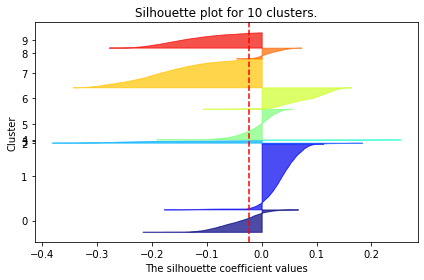

Clustering and silhouette analysis completed.
Clustering completed with SCALED data.


,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,6
1,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,4
2,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.029210,-0.660141,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,2
3,1.00028,-0.441286,2.037134,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.526262,-0.072549,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,4
4,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0,10
17825,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-1.959000,-0.660141,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0,10
17826,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.964895,0.515043,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0,1


In [17]:
## K-Means

data_for_clustering = df_scd.drop(columns=['death36'])
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))

# 클러스터링 결과 저장을 위한 변수 초기화
best_n_clusters = None
best_silhouette_avg = -1
best_silhouette_std = np.inf
best_cluster_labels = None

# Silhouette 스코어와 표준편차 저장
silhouette_scores = []
silhouette_stds = []

# 2~10 클러스터링에 대한 실루엣 분석
for n_clusters in range(2, 11):
    # K-means MiniBatch 클러스터링
    mb_kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = mb_kmeans.fit_predict(data_for_clustering.fillna(data_for_clustering.mean()))  # NaN 값 평균으로 대체

    # 실루엣 스코어 및 실루엣 값 계산
    silhouette_avg = silhouette_score(data_for_clustering.fillna(data_for_clustering.mean()), cluster_labels)
    silhouette_vals = silhouette_samples(data_for_clustering.fillna(data_for_clustering.mean()), cluster_labels)
    silhouette_std = np.std(silhouette_vals)

    silhouette_scores.append(silhouette_avg)
    silhouette_stds.append(silhouette_std)

    print(f"For {n_clusters} clusters: Silhouette Score = {silhouette_avg:.4f}, Std Dev = {silhouette_std:.4f}")

    # 표준편차가 가장 균일한 클러스터링 선택
    if silhouette_std < best_silhouette_std:
        best_n_clusters = n_clusters
        best_silhouette_avg = silhouette_avg
        best_silhouette_std = silhouette_std
        best_cluster_labels = cluster_labels

# 최적의 클러스터 수에 대한 클러스터 중심점 저장
mb_kmeans = MiniBatchKMeans(n_clusters=best_n_clusters, random_state=42)
mb_kmeans.fit(data_for_clustering.fillna(data_for_clustering.mean()))
centroids = mb_kmeans.cluster_centers_
with open(os.path.join(save_dir, "Z_object.pkl"), "wb") as f:
    pickle.dump(centroids, f)

# 최종 결과 저장
df_scd['Cluster_Labels'] = best_cluster_labels +1
# df_scd.to_csv(os.path.join(out_0830, f'clustered_data_{best_n_clusters}_clusters.csv'))

# 최적의 실루엣 스코어 및 표준편차 출력
print(f"\nBest number of clusters: {best_n_clusters}")
print(f"Best Silhouette Score: {best_silhouette_avg:.4f}")
print(f"Best Silhouette Std Dev: {best_silhouette_std:.4f}")

# Silhouette 스코어 시각화
fig, ax1 = plt.subplots(1, 1)
silhouette_vals = silhouette_samples(data_for_clustering.fillna(data_for_clustering.mean()), best_cluster_labels)
y_ticks = []
y_lower = 10
for i in range(best_n_clusters):
    ith_cluster_silhouette_values = silhouette_vals[best_cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.jet(float(i) / best_n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    y_ticks.append((y_lower + y_upper) / 2)
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster")
ax1.set_yticks(y_ticks)
ax1.set_yticklabels(range(best_n_clusters))
ax1.set_title(f"Silhouette plot for {best_n_clusters} clusters.")
ax1.axvline(x=best_silhouette_avg, color="red", linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'silhouette_plot_{best_n_clusters}_clusters.png'))
plt.show()

print("Clustering and silhouette analysis completed.")

df_scd['death36'] = df['death36']
# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with SCALED data.")
df_scd

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f886ca4b4c0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Index(['sex_sys_val', 'bir1', 'bir2', 'bir3', 'bir4', 'sterd1', 'sterd2',
       'sterd4', 'apgs1', 'apgs5',
       ...
       'menifs_13', 'menifs_31', 'menifs_17', 'menifs_8', 'menifs_6',
       'menifs_33', 'menifs_18', 'menifs_34', 'death36', 'Cluster_Labels'],
      dtype='object', length=290) 290
Index(['sex_sys_val', 'bir1', 'bir2', 'bir3', 'bir4', 'sterd1', 'sterd2',
       'sterd4', 'apgs1', 'apgs5',
       ...
       'menifs_12', 'menifs_13', 'menifs_31', 'menifs_17', 'menifs_8',
       'menifs_6', 'menifs_33', 'menifs_18', 'menifs_34', 'Cluster_Labels'],
      dtype='object', length=289) 289


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f86e4187040>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread


Number of clusters: 3
Silhouette Score: -0.0705
Silhouette Std Dev: 0.1105


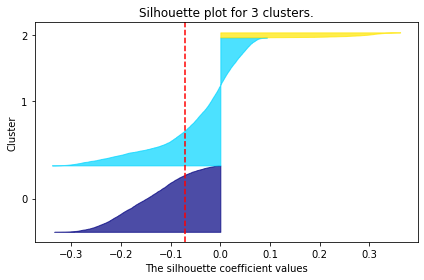

Clustering and silhouette analysis completed.
Clustering completed with SCALED data.


,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,menifs_13,menifs_31,menifs_17,menifs_8,menifs_6,menifs_33,menifs_18,menifs_34,death36,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,2
1,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,1
2,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.029210,-0.660141,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,2
3,1.00028,-0.441286,2.037134,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,0.526262,-0.072549,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,2
4,1.00028,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,-0.743127,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.467843,-1.247733,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0,1
17825,1.00028,2.266106,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-1.959000,-0.660141,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0,1
17826,-0.99972,-0.441286,-0.490886,-0.127909,-0.025952,-0.303196,1.345665,-0.035149,-0.964895,0.515043,...,-0.03179,-0.016749,-0.010592,-0.021187,0.0,-0.012973,-0.007489,-0.007489,1.0,2


In [28]:
## K-Means : Cluster 수 지정

data_for_clustering = df_scd.drop(columns=['death36'])
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))

# 클러스터 수 지정
n_clusters = 3

# K-means MiniBatch 클러스터링
mb_kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=SEED)
cluster_labels = mb_kmeans.fit_predict(data_for_clustering.fillna(data_for_clustering.mean()))  # NaN 값 평균으로 대체

# 실루엣 스코어 및 실루엣 값 계산
silhouette_avg = silhouette_score(data_for_clustering.fillna(data_for_clustering.mean()), cluster_labels)
silhouette_vals = silhouette_samples(data_for_clustering.fillna(data_for_clustering.mean()), cluster_labels)
silhouette_std = np.std(silhouette_vals)

# 클러스터 중심점 저장
centroids = mb_kmeans.cluster_centers_
with open(os.path.join(save_dir, "Z_object.pkl"), "wb") as f:
    pickle.dump(centroids, f)

# 클러스터 라벨 저장 (라벨을 1부터 시작)
df_scd['Cluster_Labels'] = cluster_labels + 1

# 최적의 실루엣 스코어 및 표준편차 출력
print(f"\nNumber of clusters: {n_clusters}")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Silhouette Std Dev: {silhouette_std:.4f}")

# Silhouette 스코어 시각화
fig, ax1 = plt.subplots(1, 1)
y_ticks = []
y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = silhouette_vals[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.jet(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    y_ticks.append((y_lower + y_upper) / 2)
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster")
ax1.set_yticks(y_ticks)
ax1.set_yticklabels(range(n_clusters))
ax1.set_title(f"Silhouette plot for {n_clusters} clusters.")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f'silhouette_plot_{n_clusters}_clusters.png'))
plt.show()

print("Clustering and silhouette analysis completed.")


df_scd['death36'] = df['death36']
# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with SCALED data.")
df_scd

In [29]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1     5936
2    11450
3      443
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
bir1              0
bir2              0
bir3              0
bir4              0
                 ..
menifs_33         0
menifs_18         0
menifs_34         0
death36           0
Cluster_Labels    0
Length: 290, dtype: int64


In [30]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [31]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,bir1,bir2,bir3,bir4,sterd1,sterd2,sterd4,apgs1,apgs5,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,2
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,1
2,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,...,0,1,0,0,0,1,0,0,0,2
3,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,...,0,1,0,0,0,1,0,0,0,2
4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17824,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,...,0,1,0,0,0,1,0,0,0,1
17825,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,6.0,...,0,1,0,0,0,1,0,0,0,1
17826,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,8.0,...,0,0,1,0,0,0,1,0,0,2


In [32]:
df_combined.to_csv(os.path.join(save_dir, "KNN_df_combined.csv"))

In [33]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                Cluster 1                     Cluster 2  \
sex_sys_val  0.5227 ± 0.4995 (1.5810e-05)  0.4868 ± 0.4998 (3.0405e-06)   
bir1         0.1385 ± 0.3454 (3.8232e-10)  0.1768 ± 0.3815 (2.5272e-11)   
bir2         0.1599 ± 0.3665 (2.8162e-16)  0.2136 ± 0.4099 (1.4403e-18)   
bir3         0.0081 ± 0.0896 (1.9168e-09)  0.0206 ± 0.1421 (1.3964e-10)   
bir4               0.0000 ± 0.0000 (n.s.)      0.0010 ± 0.0324 (0.0097)   
...                                   ...                           ...   
iperr_4          0.0008 ± 0.0290 (0.0015)      0.0000 ± 0.0000 (0.0027)   
iperroy_1    0.9420 ± 0.2337 (8.7283e-99)  0.9929 ± 0.0838 (4.9090e-86)   
iperroy_4    0.0069 ± 0.0828 (2.5152e-13)  0.0008 ± 0.0280 (8.6320e-12)   
iperroy_3    0.0462 ± 0.2098 (2.8555e-75)  0.0062 ± 0.0785 (2.2369e-65)   
iperroy_2    0.0049 ± 0.0697 (1.6887e-13)  0.0001 ± 0.0093 (3.3328e-12)   

                            Cluster 3  
sex_sys_val

In [23]:
# Wilcoxon test :: features --> P-Value 순으로 정렬

unique_clusters = df_combined['Cluster_Labels'].unique()

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for cluster in unique_clusters:
    cluster_data = df_combined[df_combined['Cluster_Labels'] == cluster]
    outside_data = df_combined[df_combined['Cluster_Labels'] != cluster]
    
    for column in df_combined.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(df_combined[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats_df.loc[column, f'Cluster {cluster}'] = f"{mean_val:.4f} ± {std_dev:.4f}"
                p_values_df.loc[column, f'Cluster {cluster}'] = p_value
            else:
                stats_df.loc[column, f'Cluster {cluster}'] = "NaN ± NaN"
                p_values_df.loc[column, f'Cluster {cluster}'] = float('nan')

# 각 특성별 최소 p-value 계산
p_values_df['min_p_value'] = p_values_df.min(axis=1)

# p-value를 기준으로 행 정렬
p_values_df = p_values_df.sort_values(by='min_p_value')

# 정렬된 순서대로 최종 DataFrame 구성
combined_df = pd.DataFrame()
for column in p_values_df.columns[:-1]:  # 'min_p_value' 제외
    formatted_values = stats_df[column].reindex(p_values_df.index).astype(str) + " (" + p_values_df[column].reindex(p_values_df.index).apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}" if x == x else "n.s.").astype(str) + ")"
    combined_df[column] = formatted_values

# 결과 출력
print("Combined Mean, Standard Deviation and P-values (sorted by feature min p-value):")
print(combined_df)

Combined Mean, Standard Deviation and P-values (sorted by feature min p-value):
                              Cluster 6                     Cluster 4  \
pdatr_15   0.0000 ± 0.0000 (0.0000e+00)  0.3040 ± 0.4610 (1.9391e-18)   
ph_1       0.0319 ± 0.1757 (3.6468e-17)  0.2952 ± 0.4571 (3.5726e-41)   
resui_1    0.6748 ± 0.4685 (6.8851e-56)  0.9119 ± 0.2841 (3.5840e-30)   
resup_1    0.8429 ± 0.3639 (1.9047e-31)  0.9031 ± 0.2965 (1.6521e-07)   
resuo_1    0.8847 ± 0.3195 (1.3625e-15)      0.9075 ± 0.2904 (0.0022)   
...                                 ...                           ...   
strdut2_1              NaN ± NaN (n.s.)              NaN ± NaN (n.s.)   
fcou_37                NaN ± NaN (n.s.)              NaN ± NaN (n.s.)   
bsffs1_1               NaN ± NaN (n.s.)              NaN ± NaN (n.s.)   
bsffs1_19              NaN ± NaN (n.s.)              NaN ± NaN (n.s.)   
menifs_6               NaN ± NaN (n.s.)              NaN ± NaN (n.s.)   

                               Cluster 2   

In [34]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

In [35]:
## DEATH RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'death36')
cmr1 = calculate_positive_rate(df_combined, 'ntet_1')
cmr2 = calculate_positive_rate(df_combined, 'iperr_2')
print(cmr, cmr1, cmr2)

             Total  death36_Pos  death36_Neg Positive Rate death36_Pos / Total
Cluster 1   5936.0        257.0       5679.0         4.33%          257 / 5936
Cluster 2  11450.0         82.0      11368.0         0.72%          82 / 11450
Cluster 3    443.0          1.0        442.0         0.23%             1 / 443              Total  ntet_Pos  ntet_Neg Positive Rate ntet_Pos / Total
Cluster 1   5936.0     836.0    5100.0        14.08%       836 / 5936
Cluster 2  11450.0     336.0   11114.0         2.93%      336 / 11450
Cluster 3    443.0       3.0     440.0         0.68%          3 / 443              Total  iperr_Pos  iperr_Neg Positive Rate iperr_Pos / Total
Cluster 1   5936.0      344.0     5592.0         5.80%        344 / 5936
Cluster 2  11450.0       81.0    11369.0         0.71%        81 / 11450
Cluster 3    443.0        0.0      443.0         0.00%           0 / 443


In [36]:
cmr.to_csv(os.path.join(save_dir, "mortality_rate_results_death36.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "mortality_rate_results_ntetPos.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "mortality_rate_results_iperrPos.csv"), encoding='utf-8-sig')